In [10]:
import random
import pandas as pd
from ISLP.models import (ModelSpec as MS)
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

import seaborn as sns
from scipy import stats
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

In [11]:
random.seed(1234)

fashion_df = pd.read_csv("./data/fashion_data.csv")
fashion_df["Order Date"] = pd.to_datetime(fashion_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
fashion_df.set_index("Order Date", inplace=True)
fashion_df.drop(columns=["Unnamed: 0"], inplace=True)


groceries_df = pd.read_csv("./data/grocery_data.csv")
groceries_df["Order Date"] = pd.to_datetime(groceries_df["Order Date"]) # Formating Order date back to Datetime dtype, in read_csv you cant set column to datetime so need to do manually
groceries_df.set_index("Order Date", inplace=True)
groceries_df.drop(columns=["Unnamed: 0"], inplace=True)

In [12]:
fashion_df.head()

,Shipping Address State,Revenue,Survey ResponseID,weather_category,age,race,education,income,gender,amazon_frequency,...,ratio_other,ratio_rain_protection,day_of_the_week,Holiday,Season,ppt,tmax,tmin,tavg,Temp_No_Season
Order Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,AL,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,25.626,13.849,4.712,9.280,NaN
2017-01-01,AR,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.999,10.667,4.430,7.548,NaN
2017-01-01,AZ,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,4.824,9.969,4.154,7.061,NaN
2017-01-01,CA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.760,9.559,0.137,4.848,NaN
2017-01-01,CO,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.385,2.787,-9.496,-3.354,NaN


In [13]:


    

def linear_reg_staates(data, var1, var2): 
    """ 
        var1: Is the first variable for the dependent variable of the linear regression
        var2: Is the second variable for the dependent variable of the linear regression
    """
    col = ["State", "Param_1", "P_value1", "Param_2", "P_value2", "R_sqrt"]
    results_lin_reg = pd.DataFrame(columns=col)
    
    states_list = fashion_df["Shipping Address State"].unique()
    

    for state in states_list: 
        df_one_state_filter = data["Shipping Address State"] == state
        df_one_state = fashion_df[df_one_state_filter].copy()


        # 365 days lagged temp column
        df_one_state["Temp_No_Season"] = df_one_state["tavg"] - df_one_state["tavg"].shift(365)
        df_one_state["Temp_No_Season"] = df_one_state["Temp_No_Season"].round(3)

        # 365 days lagged rain column
        df_one_state["Rain_No_Season"] = df_one_state["ppt"] - df_one_state["ppt"].shift(365)
        df_one_state["Rain_No_Season"] = df_one_state["Rain_No_Season"].round(3)

        # first order diff Revenue
        first_order_diff = [0]

        for j in range(1,len(df_one_state)): 
            first_order_diff.append(df_one_state["Revenue"].iloc[j] - df_one_state["Revenue"].iloc[j-1])

        df_one_state["first_order_diff_Revenue"] = first_order_diff
        df_one_state["first_order_diff_Revenue"] = df_one_state["first_order_diff_Revenue"].round(4)

        # Lag first order diff Revenue 
        df_one_state.loc[:, "first_order_diff_Revenue_lagged"] = df_one_state["first_order_diff_Revenue"].shift(-1)

        # Lag revenue by 1 day
        df_one_state.loc[:, "Revenue_lagged"] = df_one_state["Revenue"].shift(-1)

        # Because of the one day shift we create a missing entry for the last day in or DF -> we fill this with 0
        df_one_state = df_one_state.fillna(0)

        # Calc SMA7 
        df_one_state.loc[:, "SMA7_ratio_hot_weather_clothing"] = df_one_state["ratio_hot_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_cold_weather_clothing"] = df_one_state["ratio_cold_weather"].rolling(7).mean().round(2)

        df_one_state.loc[:, "SMA7_ratio_rain_weather_clothing"] = df_one_state["ratio_rain_protection"].rolling(7).mean().round(2)

        # Remove additional days for temp calculations
        df_one_state = df_one_state.iloc[365:, :]

        # Create linear time count 
        df_one_state.loc[:, 'Time'] = np.arange(len(df_one_state))
        df_one_state = df_one_state.fillna(0).infer_objects()

        x = MS(["tavg", "ppt"]).fit_transform(df_one_state)
        y = np.log(df_one_state[var1] * df_one_state[var2] + 1)
        model = sm.OLS(y, x)
        results = model.fit()

        #print(results.summary())

        next_idx = len(results_lin_reg)
        results_lin_reg.loc[next_idx] = [state, results.params.iloc[1].round(3), results.pvalues.iloc[1].round(3), 
                                results.params.iloc[2].round(3), results.pvalues.iloc[2].round(3), results.rsquared.round(3)]
        # Param 1 = tavg
        # Param 2 = ppt

    return results_lin_reg


df_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue")

df_cold_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue")


df_hot_weather_rev_lagged = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue_lagged")
df_cold_weather_rev_lagged = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue_lagged")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to 

1. SMA7_ratio_hot_weather_clothing * Revenue 
2. SMA7_ratio_cold_weather_clothing * Revenue 
3. SMA7_ratio_hot_weather_clothing * Revenue_lagged
3. SMA7_ratio_cold_weather * Revenue_lagged

In [14]:
print(df_cold_weather_rev.head())

  State  Param_1  P_value1  Param_2  P_value2  R_sqrt
0    AL   -0.008     0.001    0.001     0.499   0.006
1    AR   -0.006     0.000    0.000     0.869   0.007
2    AZ   -0.016     0.000   -0.029     0.005   0.028
3    CA   -0.024     0.000   -0.002     0.826   0.023
4    CO   -0.019     0.000   -0.029     0.030   0.032


In [15]:
"""import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

df1 = df_hot_weather_rev
df2 = df_cold_weather_rev
df3 = df_hot_weather_rev_lagged
df4 = df_cold_weather_rev_lagged

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))  # Increased height for more rows

# Position for each row - UPDATED FOR 4 POSITIONS
positions = [0, 1, 2, 3]  # Changed to 4 positions
labels = ['Cold-weather Revenue lagged', 'Hot-weather Revenue lagged', 'Cold-weather Revenue', 'Hot-weather Revenue']

dataframes = [df4, df3, df2, df1]  # Fixed to use df4 instead of df2 twice

# Plot for each dataframe
for i, (pos, label, df) in enumerate(zip(positions, labels, dataframes)):
    # Calculate statistics
    mean = df['Param_1'].mean()
    ci_lower = np.percentile(df['Param_1'], 2.5)  # 95% CI lower bound
    ci_upper = np.percentile(df['Param_1'], 97.5) # 95% CI upper bound
    
    # Plot the boxplot (custom, simplified version)
    # Plot the point estimate (mean)
    ax.plot(mean, pos, 'o', color='darkblue', markersize=8)
    
    # Plot the confidence interval
    ax.plot([ci_lower, ci_upper], [pos, pos], '-', color='darkblue', linewidth=2)
    
    # Add vertical ticks at the ends of the confidence interval
    ax.plot([ci_lower, ci_lower], [pos-0.1, pos+0.1], '-', color='darkblue', linewidth=2)
    ax.plot([ci_upper, ci_upper], [pos-0.1, pos+0.1], '-', color='darkblue', linewidth=2)
    
    # Optionally, add a box for the interquartile range
    q1 = np.percentile(df['Param_1'], 25)
    q3 = np.percentile(df['Param_1'], 75)
    rect = plt.Rectangle((q1, pos-0.2), q3-q1, 0.4, fill=True, color='lightblue', alpha=0.5)
    ax.add_patch(rect)

# Add a vertical line at x=0
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

# Set labels and title
ax.set_yticks(positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient')
ax.set_title('Average Temperature', fontsize=12)

# Set x-axis limits - UPDATED TO INCLUDE ALL 4 DATAFRAMES
all_mins = [df['Param_1'].min() for df in dataframes]
all_maxs = [df['Param_1'].max() for df in dataframes]
min_val = min(all_mins)
max_val = max(all_maxs)
ax.set_xlim([min_val - 0.1, max_val + 0.1])

# Add a border around the plot
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\nimport pandas as pd\nimport seaborn as sns\nimport numpy as np\n\ndf1 = df_hot_weather_rev\ndf2 = df_cold_weather_rev\ndf3 = df_hot_weather_rev_lagged\ndf4 = df_cold_weather_rev_lagged\n\n# Create figure\nfig, ax = plt.subplots(figsize=(10, 6))  # Increased height for more rows\n\n# Position for each row - UPDATED FOR 4 POSITIONS\npositions = [0, 1, 2, 3]  # Changed to 4 positions\nlabels = ['Cold-weather Revenue lagged', 'Hot-weather Revenue lagged', 'Cold-weather Revenue', 'Hot-weather Revenue']\n\ndataframes = [df4, df3, df2, df1]  # Fixed to use df4 instead of df2 twice\n\n# Plot for each dataframe\nfor i, (pos, label, df) in enumerate(zip(positions, labels, dataframes)):\n    # Calculate statistics\n    mean = df['Param_1'].mean()\n    ci_lower = np.percentile(df['Param_1'], 2.5)  # 95% CI lower bound\n    ci_upper = np.percentile(df['Param_1'], 97.5) # 95% CI upper bound\n    \n    # Plot the boxplot (custom, simplified version)\n    # Plot the p

In [ ]:
"""

def create_regression_table_visualization(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    
    Create a table-structured visualization of regression results for academic thesis.
    
    Structure: For each regression model:
    Row 1: [Horizontal Boxplot tavg] [Horizontal Boxplot ppt] [Horizontal Boxplot R²]
    Row 2: [P-value dist. tavg]      [P-value dist. ppt]      [Empty]
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')

    
    # Set up the figure with academic styling
    plt.style.use('seaborn-v0_8-whitegrid')
    n_models = len(df_list)
    
    # Create figure with appropriate size
    fig, axes = plt.subplots(n_models * 2, 3, figsize=(15, 4 * n_models))
    if n_models == 1:
        axes = axes.reshape(2, 3)
    
    # Define blue color palette for academic thesis
    blue_main = '#2171b5'
    blue_light = '#6baed6'
    blue_dark = '#08306b'
    
    for model_idx, (df, model_name) in enumerate(zip(df_list, regression_names)):
        base_row = model_idx * 2
        
        # Row 1, Col 1: Horizontal boxplot for tavg coefficients
        ax_tavg_box = axes[base_row, 0]
        tavg_data = df['Param_1'].values
        box1 = ax_tavg_box.boxplot([tavg_data], vert=False, patch_artist=True, widths=0.6)
        box1['boxes'][0].set_facecolor(blue_main)
        box1['boxes'][0].set_alpha(0.7)
        for element in ['whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box1[element], color=blue_dark, linewidth=1.5)
        
        ax_tavg_box.set_xlabel(f'{param1_name} Coefficient', fontsize=11, fontweight='bold')
        ax_tavg_box.set_title(f'{model_name}\n{param1_name} Coefficients', fontsize=12, fontweight='bold')
        ax_tavg_box.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax_tavg_box.grid(True, alpha=0.3)
        ax_tavg_box.set_yticklabels([])
        
        # Row 1, Col 2: Horizontal boxplot for ppt coefficients
        ax_ppt_box = axes[base_row, 1]
        ppt_data = df['Param_2'].values
        box2 = ax_ppt_box.boxplot([ppt_data], vert=False, patch_artist=True, widths=0.6)
        box2['boxes'][0].set_facecolor(blue_main)
        box2['boxes'][0].set_alpha(0.7)
        for element in ['whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box2[element], color=blue_dark, linewidth=1.5)
        
        ax_ppt_box.set_xlabel(f'{param2_name} Coefficient', fontsize=11, fontweight='bold')
        ax_ppt_box.set_title(f'{param2_name} Coefficients', fontsize=12, fontweight='bold')
        ax_ppt_box.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax_ppt_box.grid(True, alpha=0.3)
        ax_ppt_box.set_yticklabels([])
        
        # Row 1, Col 3: Horizontal boxplot for R²
        ax_r2_box = axes[base_row, 2]
        r2_data = df['R_sqrt'].values
        box3 = ax_r2_box.boxplot([r2_data], vert=False, patch_artist=True, widths=0.6)
        box3['boxes'][0].set_facecolor(blue_main)
        box3['boxes'][0].set_alpha(0.7)
        for element in ['whiskers', 'fliers', 'medians', 'caps']:
            plt.setp(box3[element], color=blue_dark, linewidth=1.5)
        
        ax_r2_box.set_xlabel('R² Values', fontsize=11, fontweight='bold')
        ax_r2_box.set_title('Model Fit (R²)', fontsize=12, fontweight='bold')
        ax_r2_box.grid(True, alpha=0.3)
        ax_r2_box.set_yticklabels([])
        
        # Row 2, Col 1: P-value distribution for tavg (normal distribution line plot)
        ax_tavg_p = axes[base_row + 1, 0]
        p_values_tavg = df['P_value1'].values
        
        # Create smooth line plot of p-value distribution
        x_range = np.linspace(0, 1, 100)
        try:
            # Fit kernel density estimation for smooth curve
            from scipy.stats import gaussian_kde
            kde_tavg = gaussian_kde(p_values_tavg)
            density_tavg = kde_tavg(x_range)
            ax_tavg_p.plot(x_range, density_tavg, color=blue_main, linewidth=2.5, alpha=0.8)
            ax_tavg_p.fill_between(x_range, density_tavg, alpha=0.3, color=blue_light)
        except:
            # Fallback to histogram if KDE fails
            ax_tavg_p.hist(p_values_tavg, bins=20, density=True, alpha=0.7, color=blue_main)
        
        ax_tavg_p.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
        ax_tavg_p.set_xlabel('P-values', fontsize=11, fontweight='bold')
        ax_tavg_p.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax_tavg_p.set_title(f'P-value Distribution\n{param1_name}', fontsize=12, fontweight='bold')
        ax_tavg_p.legend(fontsize=9)
        ax_tavg_p.grid(True, alpha=0.3)
        ax_tavg_p.set_xlim(0, 1)
        
        # Row 2, Col 2: P-value distribution for ppt (normal distribution line plot)
        ax_ppt_p = axes[base_row + 1, 1]
        p_values_ppt = df['P_value2'].values
        
        # Create smooth line plot of p-value distribution
        try:
            kde_ppt = gaussian_kde(p_values_ppt)
            density_ppt = kde_ppt(x_range)
            ax_ppt_p.plot(x_range, density_ppt, color=blue_main, linewidth=2.5, alpha=0.8)
            ax_ppt_p.fill_between(x_range, density_ppt, alpha=0.3, color=blue_light)
        except:
            # Fallback to histogram if KDE fails
            ax_ppt_p.hist(p_values_ppt, bins=20, density=True, alpha=0.7, color=blue_main)
        
        ax_ppt_p.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
        ax_ppt_p.set_xlabel('P-values', fontsize=11, fontweight='bold')
        ax_ppt_p.set_ylabel('Density', fontsize=11, fontweight='bold')
        ax_ppt_p.set_title(f'P-value Distribution\n{param2_name}', fontsize=12, fontweight='bold')
        ax_ppt_p.legend(fontsize=9)
        ax_ppt_p.grid(True, alpha=0.3)
        ax_ppt_p.set_xlim(0, 1)
        
        # Row 2, Col 3: Leave empty or add summary statistics
        ax_empty = axes[base_row + 1, 2]
        ax_empty.axis('off')
        
        # Add summary statistics text
        n_states = len(df)
        tavg_significant = np.sum(df['P_value1'] < 0.05)
        ppt_significant = np.sum(df['P_value2'] < 0.05)
        mean_r2 = np.mean(df['R_sqrt'])
        
        summary_text = f"Summary Statistics:\n\n"
        summary_text += f"States analyzed: {n_states}\n\n"
        summary_text += f"{param1_name} significant: {tavg_significant}/{n_states}\n"
        summary_text += f"({tavg_significant/n_states*100:.1f}%)\n\n"
        summary_text += f"{param2_name} significant: {ppt_significant}/{n_states}\n"
        summary_text += f"({ppt_significant/n_states*100:.1f}%)\n\n"
        summary_text += f"Mean R²: {mean_r2:.4f}"
        
        ax_empty.text(0.1, 0.5, summary_text, fontsize=11, 
                     verticalalignment='center', 
                     bbox=dict(boxstyle="round,pad=0.5", facecolor=blue_light, alpha=0.3))
    
    # Add overall title
    fig.suptitle('Regression Analysis Results Across US States', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    
    return fig"""

'\n\ndef create_regression_table_visualization(df_list, regression_names, param1_name=\'tavg\', param2_name=\'ppt\'):\n    \n    Create a table-structured visualization of regression results for academic thesis.\n    \n    Structure: For each regression model:\n    Row 1: [Horizontal Boxplot tavg] [Horizontal Boxplot ppt] [Horizontal Boxplot R²]\n    Row 2: [P-value dist. tavg]      [P-value dist. ppt]      [Empty]\n    \n    Parameters:\n    df_list: list of DataFrames, each containing regression results for one model\n    regression_names: list of strings, names for each regression model\n    param1_name: string, name of first parameter (default: \'tavg\')\n    param2_name: string, name of second parameter (default: \'ppt\')\n\n    \n    # Set up the figure with academic styling\n    plt.style.use(\'seaborn-v0_8-whitegrid\')\n    n_models = len(df_list)\n    \n    # Create figure with appropriate size\n    fig, axes = plt.subplots(n_models * 2, 3, figsize=(15, 4 * n_models))\n    if 

In [17]:
fashion_hot_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue_lagged")
fashion_cold_weather_rev = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue_lagged")


groceries_hot_weather_rev = linear_reg_staates(groceries_df, "SMA7_ratio_hot_weather_clothing", "Revenue_lagged")
groceries_cold_weather_rev = linear_reg_staates(groceries_df, "SMA7_ratio_cold_weather_clothing", "Revenue_lagged")

C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to 

## Coefficient plot

In [18]:
def create_coefficient_boxplots(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Create horizontal boxplots for tavg and ppt coefficients side by side.
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    

    plt.style.use('seaborn-v0_8-whitegrid')
    n_models = len(df_list)
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Define color palette for each regression model
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    

    positions = [-1, -0.7, -0.4, -0.1]  # Custom spacing between boxes


    # Prepare data for boxplots
    tavg_data = []
    ppt_data = []
    
    for df in df_list:
        tavg_data.append(df['Param_1'].values)
        ppt_data.append(df['Param_2'].values)
    
    # Create tavg coefficient boxplot (horizontal)
    box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
                           labels=regression_names,  positions=positions)
    
    # Color the tavg boxplots
    for patch, color in zip(box1['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box1[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_tavg.set_xlabel(f'Average Temperature Coefficient (°C)', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'Average Temperature Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_tavg.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    #ax_tavg.grid(True, alpha=0.3)
    ax_tavg.tick_params(axis='y', rotation=0)
    ax_tavg.margins(x=0.05, y=0)
   
    
    # Create ppt coefficient boxplot
    box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True, 
                        labels=[''] * len(ppt_data),  positions=positions)
    
    # Color the ppt boxplots
    for patch, color in zip(box2['boxes'], colors[:n_models]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box2[element]:
            item.set_color('#08306b')
            item.set_linewidth(1.2)
    
    ax_ppt.set_xlabel(f'Precipitation Coefficient (mm)', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'Precipitation Coefficients Distribution', fontsize=14, fontweight='bold')
    ax_ppt.axvline(x=0, color='red', linestyle='--', alpha=0.5, linewidth=2)
    #ax_ppt.grid(True, alpha=0.3)
    ax_ppt.tick_params(axis='y')
    
    # Add overall title
    fig.suptitle('Regression Coefficients Distribution Across US States', 
                fontsize=20, fontweight='bold', y=1)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    
    plt.savefig('./Exports/regression_coefficients_plot.png', dpi=300, bbox_inches='tight')
    
    return fig

C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3892068185.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = ax_tavg.boxplot(tavg_data, vert=False, patch_artist=True,
C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\3892068185.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = ax_ppt.boxplot(ppt_data, vert=False, patch_artist=True,


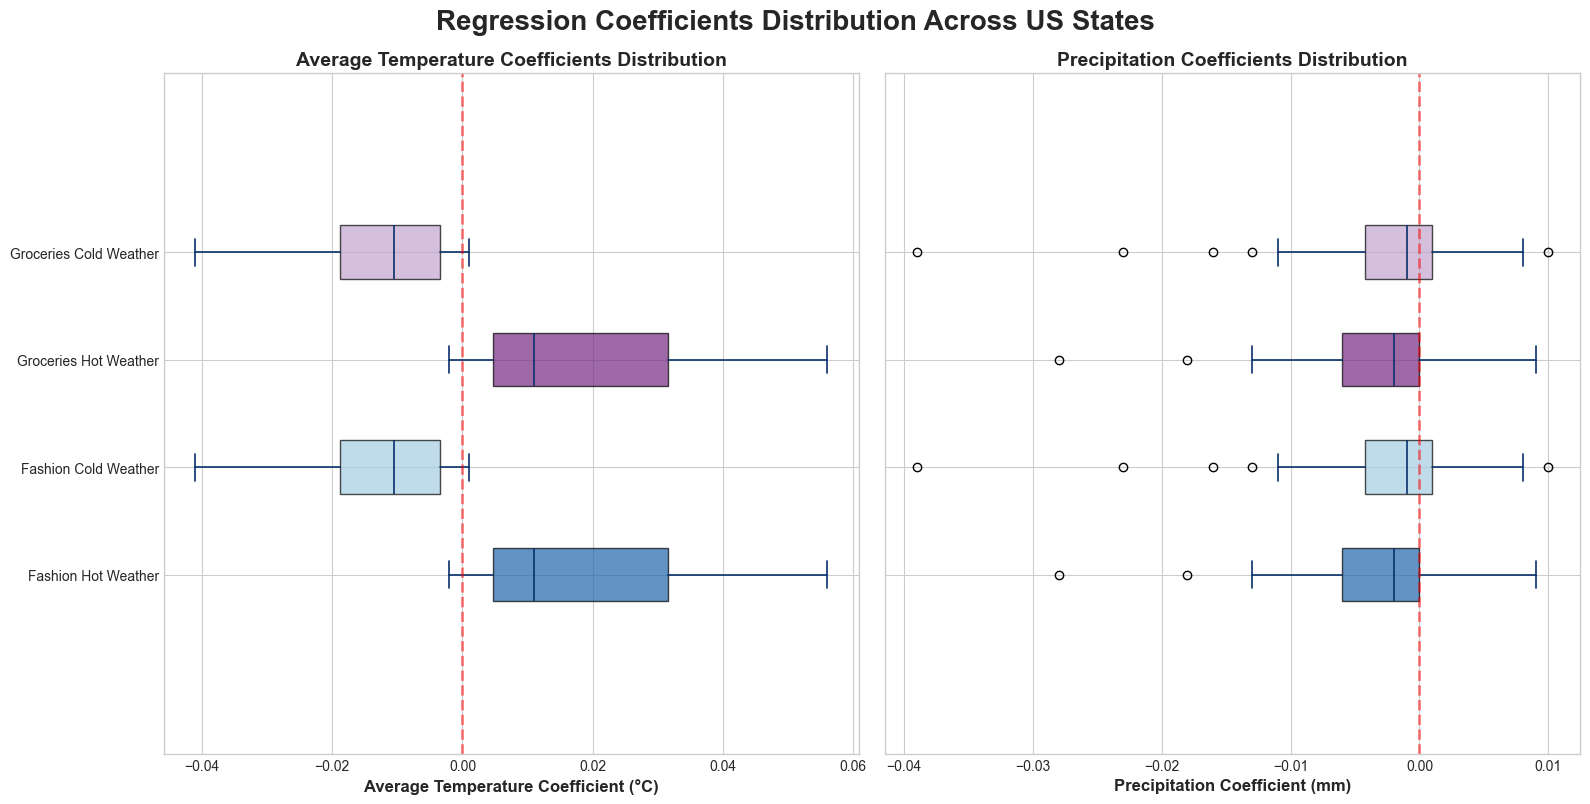

In [36]:
df_list = [fashion_hot_weather_rev, fashion_cold_weather_rev, groceries_hot_weather_rev, groceries_cold_weather_rev]
regression_names = ['Fashion Hot Weather', 'Fashion Cold Weather', 'Groceries Hot Weather', 'Groceries Cold Weather']
fig1 = create_coefficient_boxplots(df_list, regression_names)


## P-value plot

In [42]:
def create_pvalue_distributions(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Create density plots for p-value distributions of tavg and ppt parameters.
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    
    # Set up the figure with academic styling
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with two subplots side by side
    fig, (ax_tavg, ax_ppt) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Define color palette for each regression model (matching coefficient plots)
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    line_styles = ['-', '-', '-.', '--']
    
    # Import required library
    try:
        from scipy.stats import gaussian_kde
        use_kde = True
    except ImportError:
        use_kde = False
    
    x_range = np.linspace(0, 1, 100)
    
    # Plot tavg p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_tavg = df['P_value1'].values
        
        if use_kde:
            try:
                kde_tavg = gaussian_kde(p_values_tavg)
                density_tavg = kde_tavg(x_range)
                ax_tavg.plot(x_range, density_tavg, color=color, linewidth=2.5, 
                           alpha=0.8, label=name, linestyle=linestyle)
            except:
                # Fallback to histogram if KDE fails
                ax_tavg.hist(p_values_tavg, bins=20, density=True, alpha=0.4, 
                           color=color, label=name, histtype='step', linewidth=2)
        else:
            ax_tavg.hist(p_values_tavg, bins=20, density=True, alpha=0.4, 
                       color=color, label=name, histtype='step', linewidth=2)
    
    ax_tavg.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_tavg.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_tavg.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax_tavg.set_title(f'P-value Distribution - Average Temperature', fontsize=14, fontweight='bold')
    ax_tavg.legend(fontsize=10, loc='upper right')
    ax_tavg.grid(True, alpha=0.3)
    ax_tavg.set_xlim(0, 1)
    
    # Plot ppt p-value distributions
    for i, (df, name, color, linestyle) in enumerate(zip(df_list, regression_names, colors, line_styles)):
        p_values_ppt = df['P_value2'].values
        
        if use_kde:
            try:
                kde_ppt = gaussian_kde(p_values_ppt)
                density_ppt = kde_ppt(x_range)
                ax_ppt.plot(x_range, density_ppt, color=color, linewidth=2.5, 
                          alpha=0.8, label=name, linestyle=linestyle)
            except:
                # Fallback to histogram if KDE fails
                ax_ppt.hist(p_values_ppt, bins=20, density=True, alpha=0.4, 
                          color=color, label=name, histtype='step', linewidth=2)
        else:
            ax_ppt.hist(p_values_ppt, bins=20, density=True, alpha=0.4, 
                      color=color, label=name, histtype='step', linewidth=2)
    
    ax_ppt.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, linewidth=2, label='α = 0.05')
    ax_ppt.set_xlabel('P-values', fontsize=12, fontweight='bold')
    ax_ppt.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax_ppt.set_title(f'P-value Distribution - Precipitation', fontsize=14, fontweight='bold')
    ax_ppt.legend(fontsize=10, loc='upper right')
    ax_ppt.grid(True, alpha=0.3)
    ax_ppt.set_xlim(0, 1)
    
    # Add overall title
    fig.suptitle('P-value Distributions Across Regression Models', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.savefig('./Exports/regression_p_values.png', dpi=300, bbox_inches='tight')
    
    return fig

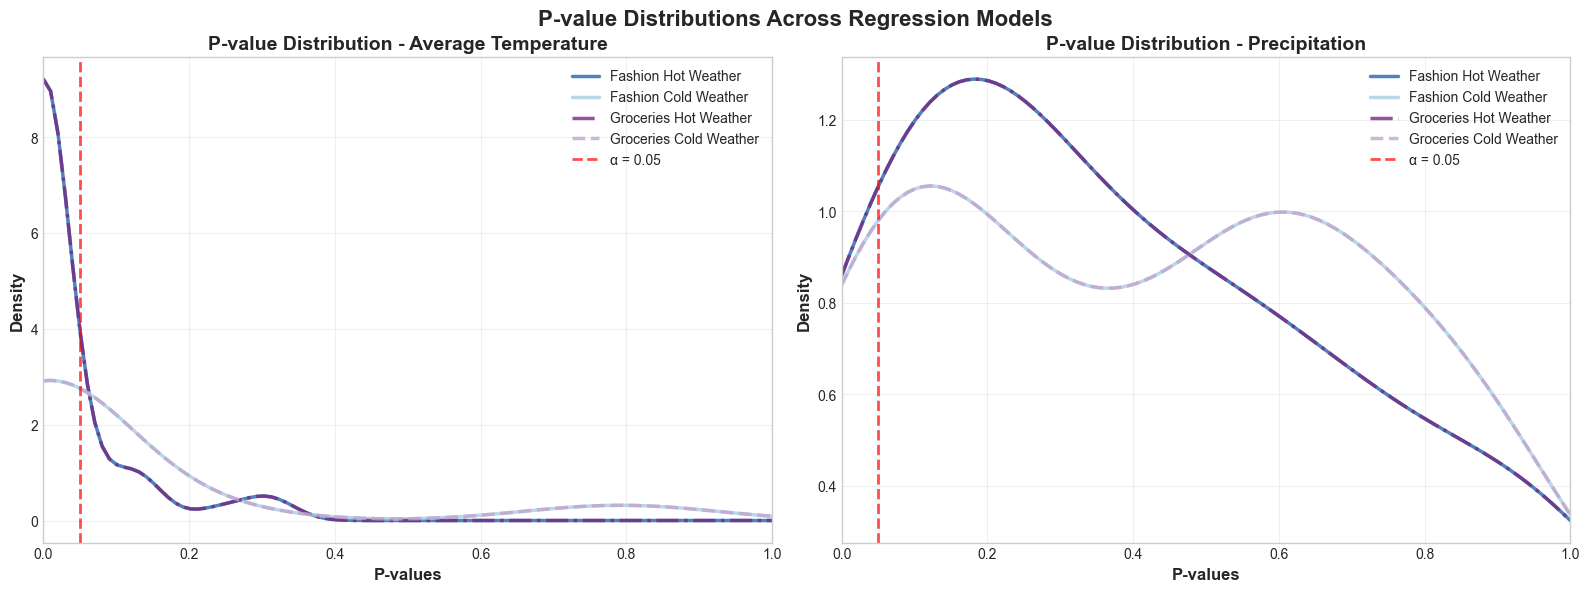

In [43]:
fig2 = create_pvalue_distributions(df_list, regression_names) 

## R^2 plot

In [58]:
def create_r_squared_boxplots(df_list, regression_names):
    """
    Create boxplots showing the distribution of R² values across regression models.
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    """
    
    # Set up the figure with academic styling
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Create figure with space for summary table below
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Updated color palette to match your specification
    colors = ['#2166ac', '#a6cee3', '#762a83', '#c2a5cf']
    
    # Prepare R² data
    r2_data = []
    for df in df_list:
        r2_data.append(df['R_sqrt'].values)
    
    # Create R² boxplot
    box = ax.boxplot(r2_data, vert=True, patch_artist=True, widths=0.6,
                     labels=regression_names)
    
    # Color the boxplots with new colors
    for patch, color in zip(box['boxes'], colors[:len(df_list)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.2)
    
    # Style other boxplot elements
    for element in ['whiskers', 'fliers', 'medians', 'caps']:
        for item in box[element]:
            item.set_color('black')
            item.set_linewidth(1.5)
    
    # Enhanced styling
    ax.set_ylabel('R² Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('Regression Models', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    # Set y-axis to start from 0 for better comparison
    ax.set_ylim(0, max([max(data) for data in r2_data]) * 1.1)
    
    # Optinal summary table
    """
    # Calculate mean R² for each model
    mean_r2_values = []
    for df in df_list:
        r2_values = df['R_sqrt'].values
        mean_r2 = np.mean(r2_values)
        mean_r2_values.append(mean_r2)
    
    # Create academic-style summary table below the plot
    table_data = []
    for name, mean_r2 in zip(regression_names, mean_r2_values):
        table_data.append([name, f"{mean_r2:.4f}"])
    
    # Add table below the plot
    table = ax.table(cellText=table_data,
                    colLabels=['Model', 'Mean R²'],
                    cellLoc='center',
                    loc='bottom',
                    bbox=[0.2, -0.35, 0.6, 0.25])
     # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    # Color table header
    for i in range(len(table_data[0])):
        table[(0, i)].set_facecolor('#f0f0f0')
        table[(0, i)].set_text_props(weight='bold')
    
    # Color table rows alternately and match boxplot colors
    for i, (row_data, color) in enumerate(zip(table_data, colors)):
        table[(i+1, 0)].set_facecolor(color)
        table[(i+1, 0)].set_alpha(0.3)
        table[(i+1, 1)].set_facecolor(color)
        table[(i+1, 1)].set_alpha(0.3)
    """
    # Add overall title
    fig.suptitle('R² Distribution Across Regression Models', 
                fontsize=18, fontweight='bold', y=0.95)
    
    # Adjust layout to accommodate table
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, bottom=0.2)

    plt.savefig('./Exports/R2_values_regression.png', dpi=300, bbox_inches='tight')
    
    return fig

C:\Users\Moritz\AppData\Local\Temp\ipykernel_14144\670654311.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(r2_data, vert=True, patch_artist=True, widths=0.6,


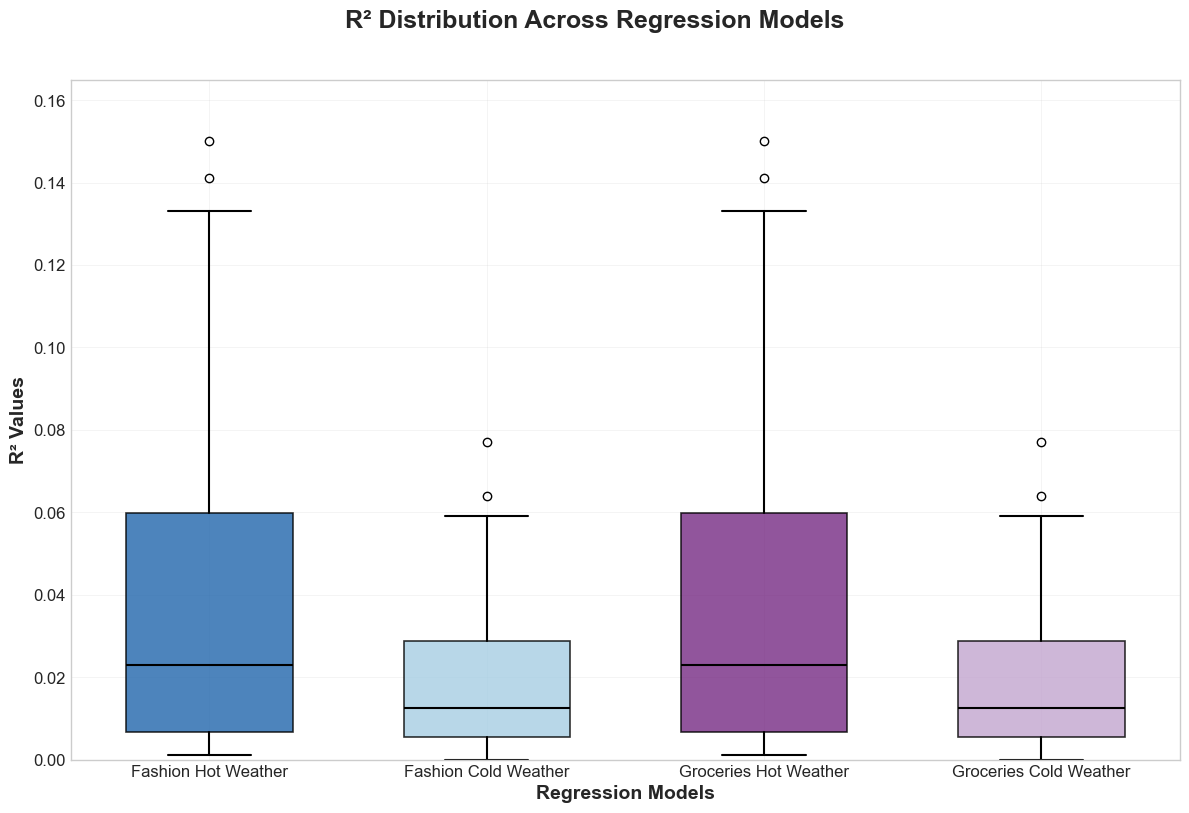

In [59]:
fig3 = create_r_squared_boxplots(df_list, regression_names)

# Old version of the Plot

In [24]:
"""import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

def create_academic_regression_visualization(df_list, regression_names, param1_name='tavg', param2_name='ppt'):
    """
    Create a clean, academic-style visualization similar to Biometrical Journal format.
    
    Layout: Clean 2x2 grid for each model with improved readability
    Row 1: [tavg coefficients] [ppt coefficients] - horizontal boxplots
    Row 2: [tavg p-values]     [ppt p-values] - distribution plots
    
    Parameters:
    df_list: list of DataFrames, each containing regression results for one model
    regression_names: list of strings, names for each regression model
    param1_name: string, name of first parameter (default: 'tavg')
    param2_name: string, name of second parameter (default: 'ppt')
    """
    
    # Set clean academic style
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 10,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })
    
    n_models = len(df_list)
    
    # Create figure with better proportions
    fig = plt.figure(figsize=(12, 2.5 * n_models))
    
    # Define professional color scheme
    colors = {
        'main': '#1f77b4',      # Professional blue
        'light': '#aec7e8',     # Light blue
        'dark': '#0d3b66',      # Dark blue
        'accent': '#d62728',    # Red for significance lines
        'background': '#f8f9fa', # Light background
        'grey': '#808080',      # Grey for density plots
        'light_grey': '#d3d3d3' # Light grey for density fill
    }
    
    # Calculate grid structure: First model gets 2 rows, subsequent models get 3 rows (empty + 2 data rows)
    total_rows = 2 + (n_models - 1) * 3
    height_ratios = [3, 2]  # First model - larger boxplot area, smaller density area
    for i in range(1, n_models):
        height_ratios.extend([0.7, 3, 2])  # Spacer (~0.5cm) + larger boxplot + smaller density
    
    # Create subplots with proper spacing
    gs = fig.add_gridspec(total_rows, 2, 
                         height_ratios=height_ratios,
                         width_ratios=[1, 1],
                         hspace=0.3, wspace=0.35,  # Increased hspace for ~0.2cm between boxplot and density
                         left=0.12, right=0.95, top=0.93, bottom=0.07)
    
    for model_idx, (df, model_name) in enumerate(zip(df_list, regression_names)):
        # Calculate row positions: first model at 0,1; subsequent models skip empty row
        if model_idx == 0:
            base_row = 0
        else:
            base_row = 2 + (model_idx - 1) * 3
        
        # Calculate statistics for consistent scaling
        tavg_data = df['Param_1'].values
        ppt_data = df['Param_2'].values
        
        # Row 1, Col 1: tavg coefficients boxplot with model name
        ax1 = fig.add_subplot(gs[base_row, 0])
        bp1 = ax1.boxplot([tavg_data], vert=False, patch_artist=True, 
                         widths=0.4, showmeans=True, meanline=True)  # Back to original smaller width
        
        # Style the boxplot
        bp1['boxes'][0].set_facecolor(colors['main'])
        bp1['boxes'][0].set_alpha(0.7)
        bp1['boxes'][0].set_edgecolor(colors['dark'])
        bp1['medians'][0].set_color(colors['dark'])
        bp1['medians'][0].set_linewidth(2)
        bp1['means'][0].set_color('white')
        bp1['means'][0].set_linewidth(2)
        
        for element in ['whiskers', 'caps']:
            plt.setp(bp1[element], color=colors['dark'], linewidth=1.2)
        for element in ['fliers']:
            plt.setp(bp1[element], marker='o', markerfacecolor=colors['light'], 
                    markeredgecolor=colors['dark'], markersize=3, alpha=0.7)
        
        ax1.axvline(x=0, color=colors['accent'], linestyle='--', alpha=0.6, linewidth=1.5)
        ax1.set_xlabel(f'{param1_name} coefficient', fontweight='bold', fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_yticklabels([])
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        
        # Keep original y-limits for proper boxplot proportions
        ax1.set_ylim(0.5, 1.5)
        
        # Fix x-axis tick formatting to prevent overlap
        ax1.tick_params(axis='x', labelsize=9, rotation=0)
        ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}' if abs(x) < 0.01 else f'{x:.2f}'))
        
        # Add model name on the left side
        ax1.text(-0.12, 0.5, model_name, transform=ax1.transAxes, 
                fontsize=10, fontweight='bold', rotation=90, 
                verticalalignment='center', horizontalalignment='center')
        
        # Row 1, Col 2: ppt coefficients boxplot
        ax2 = fig.add_subplot(gs[base_row, 1])
        bp2 = ax2.boxplot([ppt_data], vert=False, patch_artist=True, 
                         widths=0.4, showmeans=True, meanline=True)  # Back to original smaller width
        
        # Style the boxplot
        bp2['boxes'][0].set_facecolor(colors['main'])
        bp2['boxes'][0].set_alpha(0.7)
        bp2['boxes'][0].set_edgecolor(colors['dark'])
        bp2['medians'][0].set_color(colors['dark'])
        bp2['medians'][0].set_linewidth(2)
        bp2['means'][0].set_color('white')
        bp2['means'][0].set_linewidth(2)
        
        for element in ['whiskers', 'caps']:
            plt.setp(bp2[element], color=colors['dark'], linewidth=1.2)
        for element in ['fliers']:
            plt.setp(bp2[element], marker='o', markerfacecolor=colors['light'], 
                    markeredgecolor=colors['dark'], markersize=3, alpha=0.7)
        
        ax2.axvline(x=0, color=colors['accent'], linestyle='--', alpha=0.6, linewidth=1.5)
        ax2.set_xlabel(f'{param2_name} coefficient', fontweight='bold', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_yticklabels([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        
        # Keep original y-limits for proper boxplot proportions
        ax2.set_ylim(0.5, 1.5)
        
        # Fix x-axis tick formatting to prevent overlap
        ax2.tick_params(axis='x', labelsize=9, rotation=0)
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.3f}' if abs(x) < 0.01 else f'{x:.2f}'))
        
        # Row 2, Col 1: tavg p-values distribution
        ax4 = fig.add_subplot(gs[base_row + 1, 0])
        p_values_tavg = df['P_value1'].values
        
        # Create clean distribution plot with grey colors
        x_range = np.linspace(0, 1, 200)
        try:
            kde_tavg = gaussian_kde(p_values_tavg)
            density_tavg = kde_tavg(x_range)
            ax4.plot(x_range, density_tavg, color=colors['grey'], linewidth=2.5, alpha=0.9)
            ax4.fill_between(x_range, density_tavg, alpha=0.3, color=colors['light_grey'])
        except:
            # Fallback to histogram
            ax4.hist(p_values_tavg, bins=15, density=True, alpha=0.7, 
                    color=colors['grey'], edgecolor=colors['dark'])
        
        ax4.axvline(x=0.05, color=colors['accent'], linestyle='--', alpha=0.8, 
                   linewidth=2, label='α = 0.05')
        ax4.set_xlabel('p-values', fontweight='bold', fontsize=10)
        ax4.set_yticklabels([])  # Remove y-axis labels
        ax4.legend(frameon=False, fontsize=9)
        ax4.grid(True, alpha=0.3)
        ax4.set_xlim(0, 1)
        ax4.spines['top'].set_visible(False)
        ax4.spines['right'].set_visible(False)
        
        # Better x-axis formatting for p-values
        ax4.tick_params(axis='x', labelsize=9)
        ax4.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        # Row 2, Col 2: ppt p-values distribution
        ax5 = fig.add_subplot(gs[base_row + 1, 1])
        p_values_ppt = df['P_value2'].values
        
        try:
            kde_ppt = gaussian_kde(p_values_ppt)
            density_ppt = kde_ppt(x_range)
            ax5.plot(x_range, density_ppt, color=colors['grey'], linewidth=2.5, alpha=0.9)
            ax5.fill_between(x_range, density_ppt, alpha=0.3, color=colors['light_grey'])
        except:
            # Fallback to histogram
            ax5.hist(p_values_ppt, bins=15, density=True, alpha=0.7, 
                    color=colors['grey'], edgecolor=colors['dark'])
        
        ax5.axvline(x=0.05, color=colors['accent'], linestyle='--', alpha=0.8, 
                   linewidth=2, label='α = 0.05')
        ax5.set_xlabel('p-values', fontweight='bold', fontsize=10)
        ax5.set_yticklabels([])  # Remove y-axis labels
        ax5.legend(frameon=False, fontsize=9)
        ax5.grid(True, alpha=0.3)
        ax5.set_xlim(0, 1)
        ax5.spines['top'].set_visible(False)
        ax5.spines['right'].set_visible(False)
        
        # Better x-axis formatting for p-values
        ax5.tick_params(axis='x', labelsize=9)
        ax5.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # Add clean overall title
    fig.suptitle('Regression Analysis Results Across US States', 
                fontsize=14, fontweight='bold', y=0.97)
    
    # Add subtle subtitle with methodology
    fig.text(0.5, 0.94, f'Coefficient distributions and significance testing for {param1_name} and {param2_name} parameters',
             ha='center', fontsize=10, style='italic', color='gray')
    
    return fig

# Usage with your regression data:
if __name__ == "__main__":
    # Run your regression analyses

    df_list = [fashion_hot_weather_rev, fashion_cold_weather_rev, groceries_hot_weather_rev, groceries_cold_weather_rev]
    regression_names = ['Fashion Hot Weather', 'Fashion Cold Weather', 
                       'Groceries Hot Weather', 'Groceries Cold Weather']

    # Create the visualization
    fig = create_academic_regression_visualization(df_list, regression_names, 
                                                 param1_name='tavg', 
                                                 param2_name='ppt')
    
    # Save with high quality
    plt.savefig('thesis_regression_table.png', dpi=300, bbox_inches='tight')
    plt.show()"""

IndentationError: unexpected indent (3646002764.py, line 11)

C:\Users\Moritz\AppData\Local\Temp\ipykernel_20828\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_20828\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_one_state = df_one_state.fillna(0)
C:\Users\Moritz\AppData\Local\Temp\ipykernel_20828\3188885125.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to 


Summary Statistics Table:
                                     Model  Temp_Mean  Temp_Std  Temp_Sig_Pct  \
0   Hot Weather Clothing → Current Revenue     0.0190    0.0171       89.5833   
1  Cold Weather Clothing → Current Revenue    -0.0137    0.0114       79.1667   
2    Hot Weather Clothing → Lagged Revenue     0.0181    0.0174       81.2500   
3   Cold Weather Clothing → Lagged Revenue    -0.0130    0.0119       75.0000   

   Precip_Mean  Precip_Std  Precip_Sig_Pct  
0      -0.0030      0.0058           18.75  
1      -0.0029      0.0077           12.50  
2      -0.0036      0.0062           12.50  
3      -0.0029      0.0078           12.50  


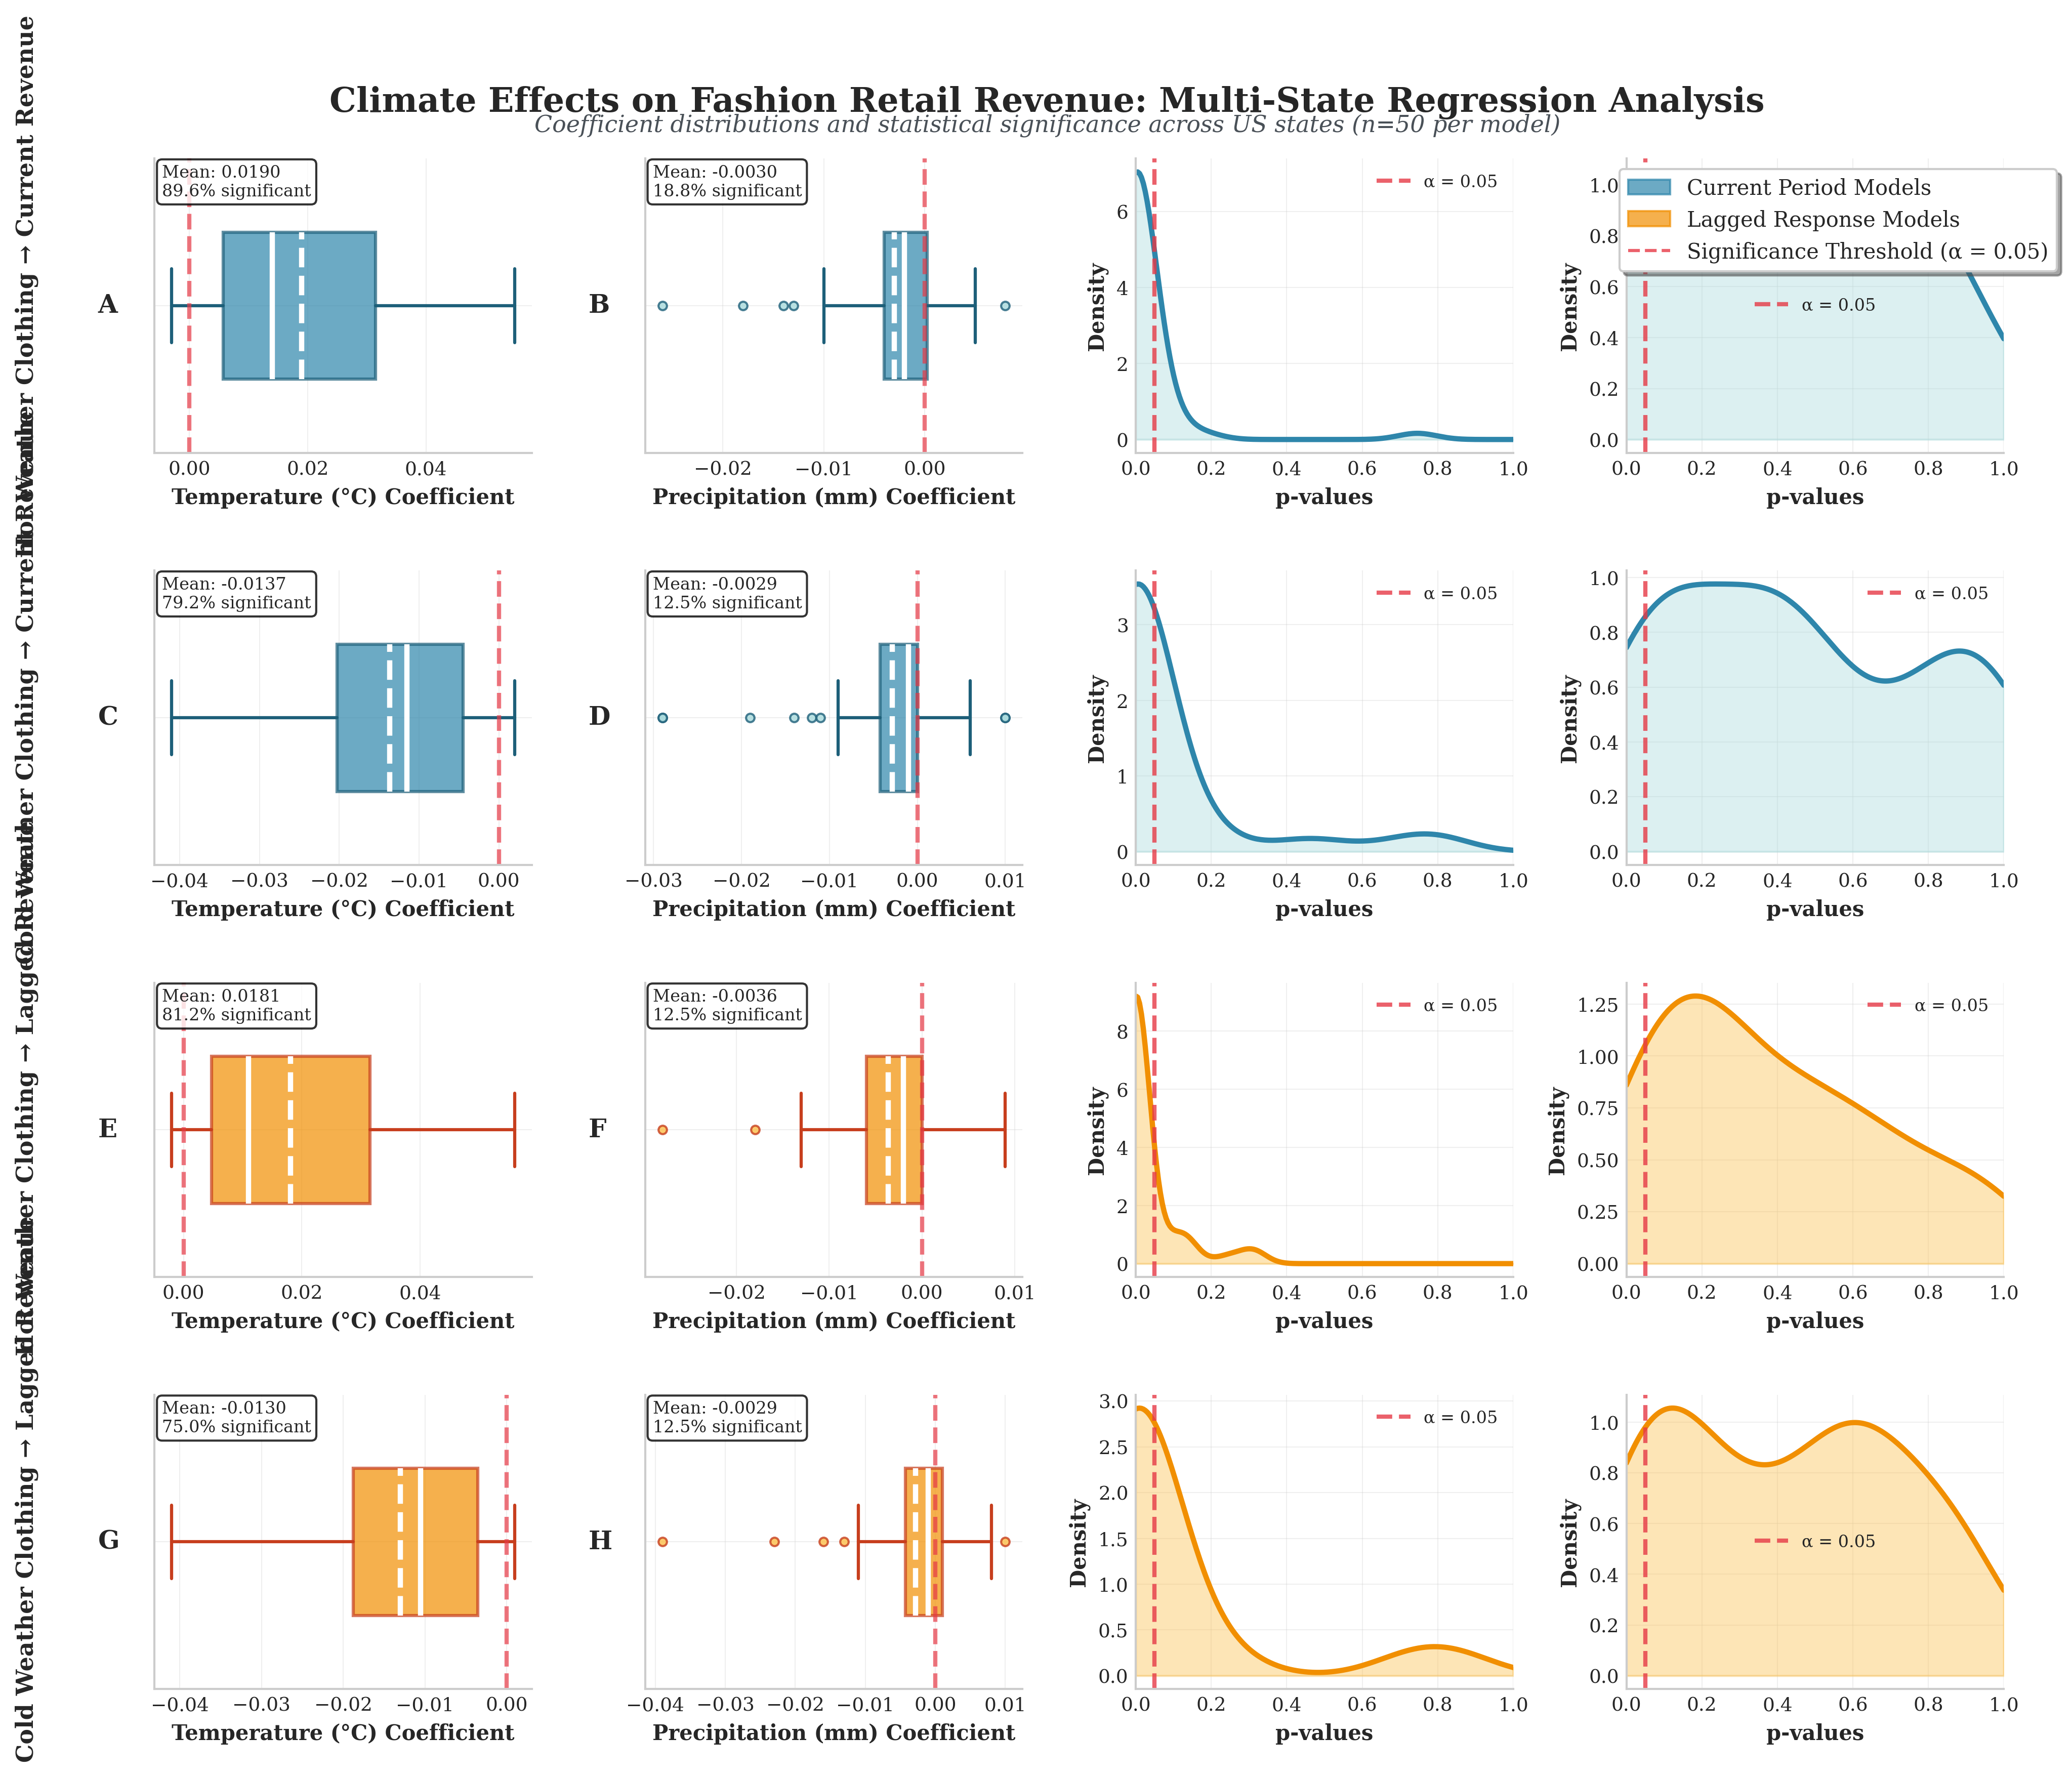

In [ ]:
"""import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

def create_enhanced_academic_visualization(df_list, regression_names, param1_name='Temperature', param2_name='Precipitation'):
    """
    Enhanced academic-style visualization with improved readability and statistical reporting.
    """
    
    # Set publication-ready style
    plt.rcParams.update({
        'font.family': 'serif',
        'font.size': 9,
        'axes.linewidth': 1.0,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        'figure.dpi': 300
    })
    
    n_models = len(df_list)
    
    # Enhanced color scheme for academic publications
    colors = {
        'current': {'main': '#2E86AB', 'light': '#A8DADC', 'dark': '#1D5F79'},  # Blue tones for current
        'lagged': {'main': '#F18F01', 'light': '#FCBF49', 'dark': '#C73E1D'},   # Orange tones for lagged
        'accent': '#E63946',      # Red for significance
        'neutral': '#6C757D',     # Grey for neutral elements
        'background': '#F8F9FA'   # Light background
    }
    
    # Create figure with optimal proportions
    fig = plt.figure(figsize=(14, 3 * n_models))
    
    # Create a more structured grid
    gs = fig.add_gridspec(n_models, 4, 
                         width_ratios=[1, 1, 1, 1],  # Equal width for all columns
                         height_ratios=[1] * n_models,
                         hspace=0.4, wspace=0.3,
                         left=0.08, right=0.95, top=0.92, bottom=0.08)
    
    for model_idx, (df, model_name) in enumerate(zip(df_list, regression_names)):
        # Determine color scheme based on model type
        is_lagged = 'Lagged' in model_name or 'lagged' in model_name.lower()
        color_scheme = colors['lagged'] if is_lagged else colors['current']
        
        # Extract data
        tavg_data = df['Param_1'].values
        ppt_data = df['Param_2'].values
        p_values_tavg = df['P_value1'].values
        p_values_ppt = df['P_value2'].values
        
        # Calculate summary statistics
        tavg_mean = np.mean(tavg_data)
        ppt_mean = np.mean(ppt_data)
        tavg_sig_pct = np.sum(p_values_tavg < 0.05) / len(p_values_tavg) * 100
        ppt_sig_pct = np.sum(p_values_ppt < 0.05) / len(p_values_ppt) * 100
        
        # Panel A: Temperature coefficients
        ax1 = fig.add_subplot(gs[model_idx, 0])
        bp1 = ax1.boxplot([tavg_data], vert=False, patch_artist=True, 
                         widths=0.5, showmeans=True, meanline=True)
        
        # Enhanced boxplot styling
        bp1['boxes'][0].set_facecolor(color_scheme['main'])
        bp1['boxes'][0].set_alpha(0.7)
        bp1['boxes'][0].set_edgecolor(color_scheme['dark'])
        bp1['boxes'][0].set_linewidth(1.5)
        bp1['medians'][0].set_color('white')
        bp1['medians'][0].set_linewidth(2.5)
        bp1['means'][0].set_color('white')
        bp1['means'][0].set_linewidth(2.5)
        
        for element in ['whiskers', 'caps']:
            plt.setp(bp1[element], color=color_scheme['dark'], linewidth=1.5)
        for element in ['fliers']:
            plt.setp(bp1[element], marker='o', markerfacecolor=color_scheme['light'], 
                    markeredgecolor=color_scheme['dark'], markersize=4, alpha=0.8)
        
        # Reference lines and formatting
        ax1.axvline(x=0, color=colors['accent'], linestyle='--', alpha=0.7, linewidth=2)
        ax1.set_xlabel(f'{param1_name} Coefficient', fontweight='bold', fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_yticklabels([])
        
        # Add summary statistics
        ax1.text(0.02, 0.98, f'Mean: {tavg_mean:.4f}\n{tavg_sig_pct:.1f}% significant', 
                transform=ax1.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Panel label
        ax1.text(-0.15, 0.5, chr(65 + model_idx*2), transform=ax1.transAxes, 
                fontsize=12, fontweight='bold', verticalalignment='center')
        
        # Panel B: Precipitation coefficients
        ax2 = fig.add_subplot(gs[model_idx, 1])
        bp2 = ax2.boxplot([ppt_data], vert=False, patch_artist=True, 
                         widths=0.5, showmeans=True, meanline=True)
        
        # Enhanced boxplot styling
        bp2['boxes'][0].set_facecolor(color_scheme['main'])
        bp2['boxes'][0].set_alpha(0.7)
        bp2['boxes'][0].set_edgecolor(color_scheme['dark'])
        bp2['boxes'][0].set_linewidth(1.5)
        bp2['medians'][0].set_color('white')
        bp2['medians'][0].set_linewidth(2.5)
        bp2['means'][0].set_color('white')
        bp2['means'][0].set_linewidth(2.5)
        
        for element in ['whiskers', 'caps']:
            plt.setp(bp2[element], color=color_scheme['dark'], linewidth=1.5)
        for element in ['fliers']:
            plt.setp(bp2[element], marker='o', markerfacecolor=color_scheme['light'], 
                    markeredgecolor=color_scheme['dark'], markersize=4, alpha=0.8)
        
        ax2.axvline(x=0, color=colors['accent'], linestyle='--', alpha=0.7, linewidth=2)
        ax2.set_xlabel(f'{param2_name} Coefficient', fontweight='bold', fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_yticklabels([])
        
        # Add summary statistics
        ax2.text(0.02, 0.98, f'Mean: {ppt_mean:.4f}\n{ppt_sig_pct:.1f}% significant', 
                transform=ax2.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Panel label
        ax2.text(-0.15, 0.5, chr(65 + model_idx*2 + 1), transform=ax2.transAxes, 
                fontsize=12, fontweight='bold', verticalalignment='center')
        
        # Panel C: Temperature p-values
        ax3 = fig.add_subplot(gs[model_idx, 2])
        
        # Enhanced distribution plot
        x_range = np.linspace(0, 1, 200)
        try:
            kde_tavg = gaussian_kde(p_values_tavg)
            density_tavg = kde_tavg(x_range)
            ax3.plot(x_range, density_tavg, color=color_scheme['main'], linewidth=2.5)
            ax3.fill_between(x_range, density_tavg, alpha=0.4, color=color_scheme['light'])
        except:
            ax3.hist(p_values_tavg, bins=20, density=True, alpha=0.7, 
                    color=color_scheme['main'], edgecolor=color_scheme['dark'])
        
        # Significance threshold and formatting
        ax3.axvline(x=0.05, color=colors['accent'], linestyle='--', alpha=0.8, 
                   linewidth=2, label='α = 0.05')
        ax3.set_xlabel('p-values', fontweight='bold', fontsize=10)
        ax3.set_ylabel('Density', fontweight='bold', fontsize=10)
        ax3.legend(frameon=False, fontsize=8)
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0, 1)
        ax3.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        # Panel D: Precipitation p-values
        ax4 = fig.add_subplot(gs[model_idx, 3])
        
        try:
            kde_ppt = gaussian_kde(p_values_ppt)
            density_ppt = kde_ppt(x_range)
            ax4.plot(x_range, density_ppt, color=color_scheme['main'], linewidth=2.5)
            ax4.fill_between(x_range, density_ppt, alpha=0.4, color=color_scheme['light'])
        except:
            ax4.hist(p_values_ppt, bins=20, density=True, alpha=0.7, 
                    color=color_scheme['main'], edgecolor=color_scheme['dark'])
        
        ax4.axvline(x=0.05, color=colors['accent'], linestyle='--', alpha=0.8, 
                   linewidth=2, label='α = 0.05')
        ax4.set_xlabel('p-values', fontweight='bold', fontsize=10)
        ax4.set_ylabel('Density', fontweight='bold', fontsize=10)
        ax4.legend(frameon=False, fontsize=8)
        ax4.grid(True, alpha=0.3)
        ax4.set_xlim(0, 1)
        ax4.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        # Add model name as row header
        fig.text(0.02, 0.85 - model_idx * 0.22, model_name, 
                fontsize=11, fontweight='bold', rotation=90, 
                verticalalignment='center', horizontalalignment='center')
    
    # Enhanced title and subtitle
    fig.suptitle('Climate Effects on Fashion Retail Revenue: Multi-State Regression Analysis', 
                fontsize=16, fontweight='bold', y=0.96)
    
    fig.text(0.5, 0.935, 
             'Coefficient distributions and statistical significance across US states (n=50 per model)',
             ha='center', fontsize=11, style='italic', color='#495057')
    
    # Add legend for model types
    legend_elements = [
        mpatches.Patch(color=colors['current']['main'], alpha=0.7, label='Current Period Models'),
        mpatches.Patch(color=colors['lagged']['main'], alpha=0.7, label='Lagged Response Models'),
        plt.Line2D([0], [0], color=colors['accent'], linestyle='--', alpha=0.8, label='Significance Threshold (α = 0.05)')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.92), 
              frameon=True, fancybox=True, shadow=True, fontsize=10)
    
    return fig

# Additional function for summary statistics table
def create_summary_table(df_list, regression_names):
    """Create a summary statistics table to accompany the visualization."""
    summary_data = []
    
    for df, name in zip(df_list, regression_names):
        tavg_data = df['Param_1'].values
        ppt_data = df['Param_2'].values
        p_values_tavg = df['P_value1'].values
        p_values_ppt = df['P_value2'].values
        
        summary_data.append({
            'Model': name,
            'Temp_Mean': np.mean(tavg_data),
            'Temp_Std': np.std(tavg_data),
            'Temp_Sig_Pct': np.sum(p_values_tavg < 0.05) / len(p_values_tavg) * 100,
            'Precip_Mean': np.mean(ppt_data),
            'Precip_Std': np.std(ppt_data),
            'Precip_Sig_Pct': np.sum(p_values_ppt < 0.05) / len(p_values_ppt) * 100
        })
    
    return pd.DataFrame(summary_data)

# Usage example:
if __name__ == "__main__":
    # Your existing regression analyses
    df1 = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue")
    df2 = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue")
    df3 = linear_reg_staates(fashion_df, "SMA7_ratio_hot_weather_clothing", "Revenue_lagged")
    df4 = linear_reg_staates(fashion_df, "SMA7_ratio_cold_weather_clothing", "Revenue_lagged")

    df_list = [df1, df2, df3, df4]
    regression_names = [
        'Hot Weather Clothing → Current Revenue',
        'Cold Weather Clothing → Current Revenue', 
        'Hot Weather Clothing → Lagged Revenue',
        'Cold Weather Clothing → Lagged Revenue'
    ]

    # Create enhanced visualization
    fig = create_enhanced_academic_visualization(
        df_list, regression_names, 
        param1_name='Temperature (°C)', 
        param2_name='Precipitation (mm)'
    )
    
    # Create summary table
    summary_df = create_summary_table(df_list, regression_names)
    print("\nSummary Statistics Table:")
    print(summary_df.round(4))
    
    # Save with publication quality
    plt.savefig('enhanced_regression_analysis.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.savefig('enhanced_regression_analysis.pdf', bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()"""